In [39]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, make_scorer, f1_score

# Algoritmos Tradicionales
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

In [44]:
# 🎯 1. Definir rutas a tus diferentes datasets VAE / Originales
base_dir = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\dataset_finales\Undersampling"

datasets_paths = {
    "codigos": os.path.join(base_dir, "Dataset_procesable.csv"),
    "descripciones": os.path.join(base_dir, "dataset_descripciones.csv"),
    "combinados": os.path.join(base_dir, "diagnosticos_combinados.csv"),
}

codes = sorted(["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"])
columnas_basura = ["DIAG PSQ", "id", "text", "Unnamed: 0", "label", "Origen"]

def cargar_y_limpiar(path):
    """Carga un CSV, auto-detecta el separador, filtra diagnósticos y separa X e y."""
    # Detectar separador (| o ,) automáticamente leyendo la primera línea
    with open(path, 'r', encoding='utf-8') as f:
        first_line = f.readline()
        sep = "|" if "|" in first_line else ","

    df = pd.read_csv(path, sep=sep)
    
    # Filtrar solo códigos objetivo
    df = df[df["DIAG PSQ"].isin(codes)].copy()
    
    # Separar variable objetivo (y)
    le = LabelEncoder()
    y = le.fit_transform(df["DIAG PSQ"])
    
    # Seleccionar características (X) excluyendo SOLO las columnas de control/metadatos
    feature_cols = [col for col in df.columns if col not in columnas_basura]
    
    # Si las columnas son de texto (como en Dataset_procesable.csv), las codificamos a números
    X_df = df[feature_cols].copy()
    for col in X_df.select_dtypes(include=['object']).columns:
        X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))
        
    X = X_df.values

    # Validación de seguridad
    if X.shape[1] == 0:
        print(f"\n❌ ERROR en archivo: {path}")
        print(f"Columnas encontradas en el CSV: {list(df.columns[:5])}...")
        raise ValueError("El dataset no contiene características numéricas válidas.")

    # Escalado de características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, le

print("✅ Cargar y limpiar actualizado correctamente.")

✅ Cargar y limpiar actualizado correctamente.


In [45]:
seed = int(time.time_ns() % (2**32))  # Semilla aleatoria basada en tiempo para reproducibilidad

# 🤖 2. Definir los modelos a comparar con configuraciones base sólidas
modelos_base = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=seed),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=seed, eval_metric='mlogloss', n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=seed),
    "CatBoost": CatBoostClassifier(iterations=100, random_state=seed, verbose=0),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=seed, verbose=-1, n_jobs=-1)
}

# 📊 3. Ejecución del Benchmark cruzado
resultados = []

print("🚀 Iniciando evaluación cruzada (5-Fold Stratified CV)...\n")

for name_ds, path_ds in datasets_paths.items():
    if not os.path.exists(path_ds):
        print(f"⚠️ Archivo no encontrado: {path_ds} (Omitiendo...)")
        continue
        
    print(f"📂 Procesando Dataset: {name_ds}")

    X, y, _ = cargar_y_limpiar(path_ds)
    
    # Validar que X no esté vacío
    if X.shape[1] == 0:
        print(f"   ⚠️ Dataset {name_ds} no tiene características válidas (omitiendo...)")
        continue
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    for name_mod, model in modelos_base.items():
        t0 = time.time()
        
        # Evaluar usando validación cruzada con F1-Score ponderado y Accuracy
        scores = cross_validate(
            model, X, y, cv=cv, 
            scoring={'f1_weighted': 'f1_weighted', 'accuracy': 'accuracy'},
            n_jobs=-1
        )
        
        t_exec = time.time() - t0
        
        f1_mean = scores['test_f1_weighted'].mean()
        acc_mean = scores['test_accuracy'].mean()
        
        resultados.append({
            "Dataset": name_ds,
            "Modelo": name_mod,
            "F1-Score": f1_mean,
            "Accuracy": acc_mean,
            "Tiempo (s)": round(t_exec, 2)
        })
        print(f"   ├─ {name_mod:<24} -> F1: {f1_mean:.4f} | Acc: {acc_mean:.4f} ({t_exec:.1f}s)")

df_res = pd.DataFrame(resultados)
print("\n✅ ¡Benchmark completado!")

🚀 Iniciando evaluación cruzada (5-Fold Stratified CV)...

📂 Procesando Dataset: codigos
   ├─ Logistic Regression      -> F1: 0.3054 | Acc: 0.4325 (46.4s)
   ├─ Random Forest            -> F1: 0.4062 | Acc: 0.4522 (49.0s)
   ├─ SVM (RBF)                -> F1: 0.2879 | Acc: 0.4486 (37.8s)
   ├─ XGBoost                  -> F1: 0.4265 | Acc: 0.4531 (3.5s)
   ├─ Gradient Boosting        -> F1: 0.4401 | Acc: 0.4755 (6.3s)
   ├─ CatBoost                 -> F1: 0.4191 | Acc: 0.4495 (7.7s)
   ├─ LightGBM                 -> F1: 0.4205 | Acc: 0.4504 (147.6s)
📂 Procesando Dataset: descripciones
   ├─ Logistic Regression      -> F1: 0.3052 | Acc: 0.4450 (0.1s)
   ├─ Random Forest            -> F1: 0.4168 | Acc: 0.4611 (0.5s)
   ├─ SVM (RBF)                -> F1: 0.2917 | Acc: 0.4450 (0.3s)
   ├─ XGBoost                  -> F1: 0.4222 | Acc: 0.4486 (0.7s)
   ├─ Gradient Boosting        -> F1: 0.4465 | Acc: 0.4790 (2.8s)
   ├─ CatBoost                 -> F1: 0.4178 | Acc: 0.4513 (2.6s)
   ├─ LightGB

🏆 RANKING GLOBAL DE MODELOS Y DATASETS:


,Dataset,Modelo,F1-Score,Accuracy,Tiempo (s)
0,combinados,LightGBM,0.654567,0.711569,3.37
1,combinados,XGBoost,0.653091,0.705389,1.07
2,descripciones,XGBoost,0.651662,0.708924,0.77
3,codigos,XGBoost,0.649447,0.705831,1.16
4,codigos,LightGBM,0.648377,0.705832,3.48
5,descripciones,LightGBM,0.647565,0.702298,3.43
6,combinados,Gradient Boosting,0.645548,0.721733,2.79
7,combinados,CatBoost,0.644937,0.719073,3.22
8,codigos,CatBoost,0.644570,0.720407,3.23
9,descripciones,CatBoost,0.639772,0.716875,2.56


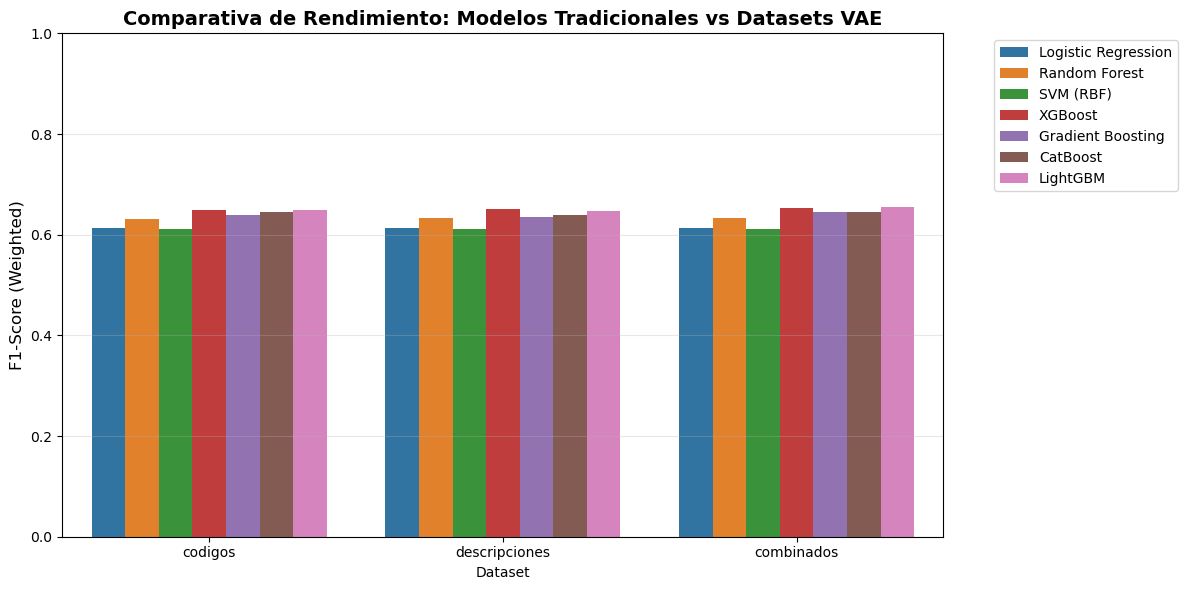

In [42]:
# 📊 Mostrar la tabla ordenada por F1-Score descendente
print("🏆 RANKING GLOBAL DE MODELOS Y DATASETS:")
df_sorted = df_res.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_sorted)

# 🎨 Gráfico comparativo por Dataset y Modelo
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Dataset", y="F1-Score", hue="Modelo", palette="tab10")
plt.title("Comparativa de Rendimiento: Modelos Tradicionales vs Datasets VAE", fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel("F1-Score (Weighted)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# 🎯 Selecciona aquí el Dataset y el Modelo Ganador tras ver los resultados
target_dataset_key = "VAE_Sintetico"   # Cambia por el mejor dataset
X, y, le_classes = cargar_y_limpiar(datasets_paths[target_dataset_key])

print(f"🛠️ Ajustando hiperparámetros sobre el dataset: {target_dataset_key}")

# 1. Definir la rejilla de búsqueda según el modelo que haya ganado
# (Ejemplo para GradientBoosting / HistGradientBoosting / XGBoost)
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Modelo base a optimizar (Ajusta al modelo que haya ganado en la Celda 4)
estimator_base = HistGradientBoostingClassifier(random_state=seed)

# 2. Búsqueda Aleatoria Inteligente
search = RandomizedSearchCV(
    estimator=estimator_base,
    param_distributions=param_distributions,
    n_iter=30,                    # Explora 30 combinaciones óptimas
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    random_state=seed,
    verbose=1
)

print("⏳ Optimizando hiperparámetros...")
search.fit(X, y)

print("\n🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(search.best_params_)
print(f"Mejor F1-Score en CV: {search.best_score_:.4f}")

# 3. Reporte detallado del modelo optimizado
best_model = search.best_estimator_
y_pred = best_model.predict(X)

print("\n📊 Reporte de Clasificación con el Modelo Final Optimizado:")
print(classification_report(y, y_pred, target_names=le_classes.classes_))

KeyError: 'VAE_Sintetico'